# Copula TrueMeasure Examples

This notebook collects copula-based `TrueMeasure` examples. It demonstrates Gaussian, Student-t, Clayton, Gumbel, and Frank copulas within the same transformation workflow.

## What Is Happening?

The point of a copula is to separate two questions that are often mixed together:

- What does each coordinate look like by itself?
- How do the coordinates move together?

If $U$ is a vector of independent uniforms from a QMC sampler, a copula turns it into dependent uniforms $V$, where both $U$ and $V$ live in the unit cube $[0,1]^d$. The marginal quantile functions then turn those uniforms into the final target variables:

$$
U \in [0, 1]^d \;\longrightarrow\; V = T_{\mathrm{copula}}(U) \in [0, 1]^d \;\longrightarrow\; X_j = F_j^{-1}(V_j).
$$

The copula changes the dependence structure. The marginal quantile functions change the one-dimensional distributions. In SciPy, this inverse CDF is the quantile function (`ppf`, SciPy's inverse CDF function).

## Copula Notation Used In This Notebook

Let

$$
U=(U_1,\ldots,U_d)\in[0,1]^d
$$

denote the original independent uniform input points produced by IID Monte Carlo or QMC.

A copula sampling transform is written as

$$
T:[0,1]^d\rightarrow[0,1]^d.
$$

It maps independent uniforms into dependent uniforms:

$$
V=T(U), \qquad V=(V_1,\ldots,V_d)\in[0,1]^d.
$$

The coordinates of $V$ are still uniform marginally, but they are no longer independent. This $U\rightarrow V$ step is the dependence layer added by the copula.

The copula CDF is written as

$$
C:[0,1]^d\rightarrow[0,1],
$$

and describes the joint distribution of $V$:

$$
C(v_1,\ldots,v_d)
=
P(V_1\le v_1,\ldots,V_d\le v_d).
$$

So $T$ and $C$ are different objects:

- $T$ is a sampling transform from the unit cube to the unit cube.
- $C$ is a cumulative distribution function from the unit cube to $[0,1]$.

After the copula step, marginal quantile functions can be applied:

$$
X_j=F_j^{-1}(V_j), \qquad j=1,\ldots,d.
$$

In SciPy, $F_j^{-1}$ is the quantile function (`ppf`, SciPy's inverse CDF function).

Thus the full workflow is:

$$
U \rightarrow V=T(U) \rightarrow X.
$$

The copula transform controls dependence. The marginal quantile functions control the final one-dimensional distributions.

This notation follows Cambou, Hofert, and Lemieux (2016, Section 1, pp. 1-2) for the separation $H(x)=C(F_1(x_1),\ldots,F_d(x_d))$, the marginal quantile functions $F_j^{-1}$, and the copula sampling transform viewpoint. The basic copula definition follows Nelsen (2006, Definition 2.2.2, pp. 10-11), and the multivariate version follows Nelsen (2006, Definition 2.10.6, p. 45).

## Why Add Copulas?

QMCPy already had `TrueMeasure` classes that transform uniform QMC points into target samples. For example, `Gaussian` can create multivariate normal samples, and `StudentT` can create multivariate Student-t samples. `SciPyWrapper` can also use SciPy distributions as marginals.

The limitation is that dependence and marginals were often tied together. If we used a multivariate Gaussian, we got Gaussian marginals with Gaussian-style dependence. If we used independent SciPy marginals, the marginals were flexible, but the coordinates did not have a separate dependence model unless we supplied a specific joint distribution.

Copulas add a middle layer:

$$
\text{independent QMC uniforms} \;\longrightarrow\; \text{dependent copula uniforms} \;\longrightarrow\; \text{marginal quantile transforms}.
$$

This is useful because we can choose the marginal distributions and the dependence pattern separately. For example, we can use beta and gamma marginals but still choose Gaussian dependence, Student-t joint-tail behavior, Clayton lower-tail dependence, Gumbel upper-tail dependence, or Frank balanced dependence.

So the benefit is not that copulas replace the existing true measures. They extend the current workflow by making dependence easier to swap, compare, and test while keeping the usual QMCPy sampling interface.

The basic workflow is:

1. generate uniform QMC samples,
2. transform them into dependent uniforms with a copula,
3. apply marginal quantile functions,
4. inspect the final dependent target samples.

## References and notation sources

The notation in this notebook follows the standard copula separation between marginal distributions and dependence.

Cambou, Hofert, and Lemieux (2016, Section 1, pp. 1-2) write a copula model as

$$
H(x)=C(F_1(x_1),\ldots,F_d(x_d)),
$$

where $F_1,\ldots,F_d$ are the marginal distribution functions and $C:[0,1]^d\rightarrow[0,1]$ is the copula. The same section rewrites the expectation in terms of a random vector $U=(U_1,\ldots,U_d)$ with distribution function $C$, and defines the marginal quantile functions $F_j^{-1}$. This is the notation used here for the final marginal step

$$
X_j=F_j^{-1}(V_j).
$$

Cambou, Hofert, and Lemieux (2016, Section 1, p. 2) also introduce the QMC sampling viewpoint used in this notebook. They start with low-discrepancy points $P_n=\{v_1,\ldots,v_n\}\subseteq[0,1)^k$ and use a copula sampling transform $\phi_C$ such that

$$
\phi_C(U^0)\sim C.
$$

In this notebook, the same copula sampling transform is written as $T$, and its output is written as

$$
V=T(U).
$$

Nelsen (2006) is used as the main introductory source for copula definitions, Sklar's theorem, Archimedean copulas, and tail dependence. The following parts are used directly:

- Chapter 2, Section 2.2, pp. 10-14: basic copula definitions. Definition 2.2.2 defines a two-dimensional copula as a function $C:I^2\rightarrow I$ satisfying the copula boundary and 2-increasing conditions.
- Chapter 2, Section 2.3, pp. 17-21: Sklar's theorem. Theorem 2.3.3 states that a joint distribution function $H$ with margins $F$ and $G$ can be written as

  $$
  H(x,y)=C(F(x),G(y)).
  $$

- Chapter 2, Section 2.9, pp. 40-42: random variate generation from copulas, including the conditional distribution method.
- Chapter 2, Section 2.10, pp. 42-48: multivariate copulas. Definition 2.10.6 defines an $n$-copula, and Theorem 2.10.9 gives Sklar's theorem in $n$ dimensions.
- Chapter 4, Section 4.1, pp. 109-113: Archimedean copula definitions and generators.
- Chapter 4, Section 4.2, pp. 114-120: one-parameter Archimedean copula families, including the Clayton, Gumbel-Hougaard, and Frank families listed in Table 4.1.
- Chapter 4, Section 4.6, pp. 151-155: multivariate Archimedean copulas.
- Chapter 5, Section 5.4, pp. 214-216: tail dependence. Definition 5.4.1 defines upper and lower tail dependence, Theorem 5.4.2 expresses tail dependence in terms of the copula, and Corollary 5.4.3 gives tail-dependence formulas for Archimedean copulas.

### Bibliography

Cambou, M., Hofert, M., and Lemieux, C. (2016). *Quasi-random numbers for copula models*. Statistics and Computing, 27, 1307-1329.

Nelsen, R. B. (2006). *An Introduction to Copulas* (2nd ed.). Springer.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

from qmcpy.discrete_distribution import DigitalNetB2, IIDStdUniform
from qmcpy.true_measure import ClaytonCopula, FrankCopula, GaussianCopula, GumbelCopula, StudentTCopula

In [2]:
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

## Helpers

In [3]:
def summarize(name, samples):
    corr = np.corrcoef(samples.T)[0, 1]
    means = samples.mean(axis=0)
    print(f"{name}")
    print(f"  shape: {samples.shape}")
    print(f"  means: {means}")
    print(f"  empirical correlation: {corr:.3f}")


def gaussian_copula_uniforms(u, correlation):
    eps = np.finfo(float).eps
    corr = np.asarray(correlation, dtype=float)
    z = stats.norm.ppf(np.clip(u, eps, 1.0 - eps))
    z_dep = z @ np.linalg.cholesky(corr).T
    return np.clip(stats.norm.cdf(z_dep), eps, 1.0 - eps)


def add_scatter(ax, samples, title, xlabel, ylabel, color):
    corr = np.corrcoef(samples.T)[0, 1]
    ax.scatter(samples[:, 0], samples[:, 1], s=10, alpha=0.65, color=color, linewidth=0)
    ax.set_title(f"{title}\nr = {corr:.3f}", fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

## Build Copula Measures

This cell builds several `TrueMeasure` objects. Each one can be called with $n$ to produce an $(n, d)$ array of samples.

Each measure changes a different part of the transformation:

- Independent normal example: the correlation matrix is the identity matrix, so the two coordinates stay independent before the normal quantile function (`ppf`, SciPy's inverse CDF function) is applied.
- Gaussian copula example: uniforms are changed to normal scores using $\Phi^{-1}$, correlated with a Cholesky factor, changed back to uniforms using $\Phi$, then sent through the marginal quantile functions (`ppf`, SciPy's inverse CDF function). This is a good choice when ordinary correlation is the main dependence pattern.
- Student-t copula example: the dependence is similar to Gaussian in the middle, but it makes joint extreme values more likely. This is useful when large or small outcomes may arrive together.
- Clayton copula example: its copula CDF is

$$
C_\theta(u_1,\ldots,u_d)=\left(\sum_{j=1}^d u_j^{-\theta}-d+1\right)^{-1/\theta}.
$$

  This puts extra dependence in the lower tail, so it is useful when low outcomes tend to happen together.
- Gumbel copula example: its copula CDF is

$$
C_\theta(u_1,\ldots,u_d)=\exp\!\left[-\left(\sum_{j=1}^d(-\log u_j)^\theta\right)^{1/\theta}\right].
$$

  This puts extra dependence in the upper tail, so it is useful when high outcomes tend to happen together.
- Frank copula example: dependence is more balanced, without a strong lower-tail or upper-tail focus. This is useful when the variables move together, but not mainly because of one extreme tail.

The 2D samples are used for plots. The 3D Clayton and Gumbel samples show that those implementations also work beyond two dimensions.

The Archimedean copula examples follow Nelsen (2006, Chapter 4). The Clayton, Gumbel-Hougaard, and Frank families are listed in Table 4.1 in Section 4.2, pp. 116-120. The multivariate Archimedean discussion follows Section 4.6, pp. 151-155.

In [4]:
n = 2048

# The identity correlation matrix gives the independent baseline case.
independent_normals = GaussianCopula(
    sampler=DigitalNetB2(2, seed=7),
    marginals=[stats.norm(), stats.norm()],
    correlation=np.eye(2),
)

positive_normal_gaussian = GaussianCopula(
    sampler=DigitalNetB2(2, seed=7),
    marginals=[stats.norm(), stats.norm()],
    correlation=[[1.0, 0.75], [0.75, 1.0]],
)

beta_gamma_gaussian = GaussianCopula(
    sampler=DigitalNetB2(2, seed=11),
    marginals=[stats.beta(a=2, b=5), stats.gamma(a=3, scale=2)],
    correlation=[[1.0, 0.65], [0.65, 1.0]],
)

beta_gamma_student_t = StudentTCopula(
    sampler=DigitalNetB2(2, seed=11),
    marginals=[stats.beta(a=2, b=5), stats.gamma(a=3, scale=2)],
    correlation=[[1.0, 0.65], [0.65, 1.0]],
    df=4,
)

student_t_normals = StudentTCopula(
    sampler=DigitalNetB2(2, seed=7),
    marginals=[stats.norm(), stats.norm()],
    correlation=[[1.0, 0.75], [0.75, 1.0]],
    df=4,
)

clayton_theta = 2.0
clayton_tau = clayton_theta / (clayton_theta + 2.0)
gaussian_rho_tau_matched = np.sin(np.pi * clayton_tau / 2.0)

lower_tail_gaussian = GaussianCopula(
    sampler=DigitalNetB2(2, seed=17),
    marginals=[stats.uniform(), stats.uniform()],
    correlation=[[1.0, gaussian_rho_tau_matched], [gaussian_rho_tau_matched, 1.0]],
)

lower_tail_clayton = ClaytonCopula(
    sampler=DigitalNetB2(2, seed=17),
    marginals=[stats.uniform(), stats.uniform()],
    theta=clayton_theta,
)

clayton_three_dim = ClaytonCopula(
    sampler=DigitalNetB2(3, seed=21),
    marginals=[stats.uniform(), stats.uniform(), stats.uniform()],
    theta=clayton_theta,
)

gumbel_theta = 2.0
gumbel_tau = 1.0 - 1.0 / gumbel_theta
gaussian_rho_gumbel_tau_matched = np.sin(np.pi * gumbel_tau / 2.0)

upper_tail_gaussian = GaussianCopula(
    sampler=DigitalNetB2(2, seed=19),
    marginals=[stats.uniform(), stats.uniform()],
    correlation=[
        [1.0, gaussian_rho_gumbel_tau_matched],
        [gaussian_rho_gumbel_tau_matched, 1.0],
    ],
)

upper_tail_gumbel = GumbelCopula(
    sampler=DigitalNetB2(2, seed=19),
    marginals=[stats.uniform(), stats.uniform()],
    theta=gumbel_theta,
)

gumbel_three_dim = GumbelCopula(
    sampler=DigitalNetB2(3, seed=25),
    marginals=[stats.uniform(), stats.uniform(), stats.uniform()],
    theta=gumbel_theta,
)

frank_theta = 6.0
frank_uniforms = FrankCopula(
    sampler=DigitalNetB2(2, seed=23),
    marginals=[stats.uniform(), stats.uniform()],
    theta=frank_theta,
)

samples = {
    "independent_normals": independent_normals(n),
    "positive_normal_gaussian": positive_normal_gaussian(n),
    "beta_gamma_gaussian": beta_gamma_gaussian(n),
    "beta_gamma_student_t": beta_gamma_student_t(n),
    "student_t_normals": student_t_normals(n),
    "lower_tail_gaussian": lower_tail_gaussian(n),
    "lower_tail_clayton": lower_tail_clayton(n),
    "clayton_three_dim": clayton_three_dim(n),
    "upper_tail_gaussian": upper_tail_gaussian(n),
    "upper_tail_gumbel": upper_tail_gumbel(n),
    "gumbel_three_dim": gumbel_three_dim(n),
    "frank_uniforms": frank_uniforms(n),
}

In [5]:
summarize("Independent standard-normal marginals", samples["independent_normals"])
summarize("Gaussian copula with normal marginals", samples["positive_normal_gaussian"])
summarize("Gaussian copula with beta and gamma marginals", samples["beta_gamma_gaussian"])
summarize("Student-t copula with beta and gamma marginals", samples["beta_gamma_student_t"])
summarize("Clayton copula dependent uniforms", samples["lower_tail_clayton"])
summarize("Clayton copula dependent uniforms, d=3", samples["clayton_three_dim"])
summarize("Gumbel copula dependent uniforms", samples["upper_tail_gumbel"])
summarize("Gumbel copula dependent uniforms, d=3", samples["gumbel_three_dim"])
summarize("Frank copula dependent uniforms", samples["frank_uniforms"])

Independent standard-normal marginals
  shape: (2048, 2)
  means: [4.31660971e-05 3.41166947e-04]
  empirical correlation: -0.001
Gaussian copula with normal marginals
  shape: (2048, 2)
  means: [4.31660971e-05 2.58035297e-04]
  empirical correlation: 0.750
Gaussian copula with beta and gamma marginals
  shape: (2048, 2)
  means: [0.28570682 5.99933011]
  empirical correlation: 0.634
Student-t copula with beta and gamma marginals
  shape: (2048, 2)
  means: [0.28570682 6.0014683 ]
  empirical correlation: 0.628
Clayton copula dependent uniforms
  shape: (2048, 2)
  means: [0.5        0.50002448]
  empirical correlation: 0.682
Clayton copula dependent uniforms, d=3
  shape: (2048, 3)
  means: [0.5        0.49999303 0.4999871 ]
  empirical correlation: 0.682
Gumbel copula dependent uniforms
  shape: (2048, 2)
  means: [0.5        0.49986997]
  empirical correlation: 0.682
Gumbel copula dependent uniforms, d=3
  shape: (2048, 3)
  means: [0.5        0.50001249 0.50001994]
  empirical cor

### Interpreting The Printed Summary

The `shape` line checks that the output has the expected size. For example, $(2048, 2)$ means 2048 transformed QMC points in 2 dimensions, and $(2048, 3)$ means 2048 points in 3 dimensions. For the 3D summaries, the displayed empirical correlation is the correlation between the first two coordinates.

The means check whether the requested marginals are preserved:

- Standard normal marginals should have mean $0$; the printed means are close to zero.
- Uniform marginals should have mean $1/2$; the Clayton, Gumbel, and Frank copula uniforms have means close to $0.5$.
- $\mathrm{Beta}(2, 5)$ has mean $2/(2 + 5) = 0.286$, matching the printed beta means near $0.2857$.
- $\mathrm{Gamma}(a=3, \mathrm{scale}=2)$ has mean $a \times \mathrm{scale} = 6$, matching the printed gamma means near $6$.

The empirical correlation is a quick check of dependence. A Gaussian copula with normal marginals and target correlation $\rho = 0.75$ gives an empirical correlation near $0.750$, which is what we expect. When the same kind of copula is paired with beta and gamma marginals, the correlation changes to about $0.634$. This happens because the beta and gamma marginal quantile functions (`ppf`, SciPy's inverse CDF function) bend the scales. The order of the points is still related, but Pearson correlation can change after nonlinear marginal transforms.

For Clayton, Gumbel, and Frank, the samples shown here are still uniform, so the means stay near $0.5$. Their correlations are positive, but the main difference is where the dependence appears: Clayton is stronger near small values, Gumbel is stronger near large values, and Frank is more balanced.

## Compare Final Samples

These summaries and plots answer two questions at once.

First, the printed `shape` confirms that we get one row per QMC point and one column per coordinate. Second, the empirical correlation gives a quick dependence summary. Correlation does not explain everything, especially for tail-dependent copulas, but it is a useful first check.

In the plots below, compare what changed:

- The first panel is independent normal marginals.
- The second keeps normal marginals but adds Gaussian copula dependence.
- The third keeps Gaussian copula dependence but changes the marginals to beta and gamma.
- The fourth keeps beta and gamma marginals but changes the dependence from Gaussian to Student-t.

That is the main copula idea in one picture: we can change dependence and marginals separately.

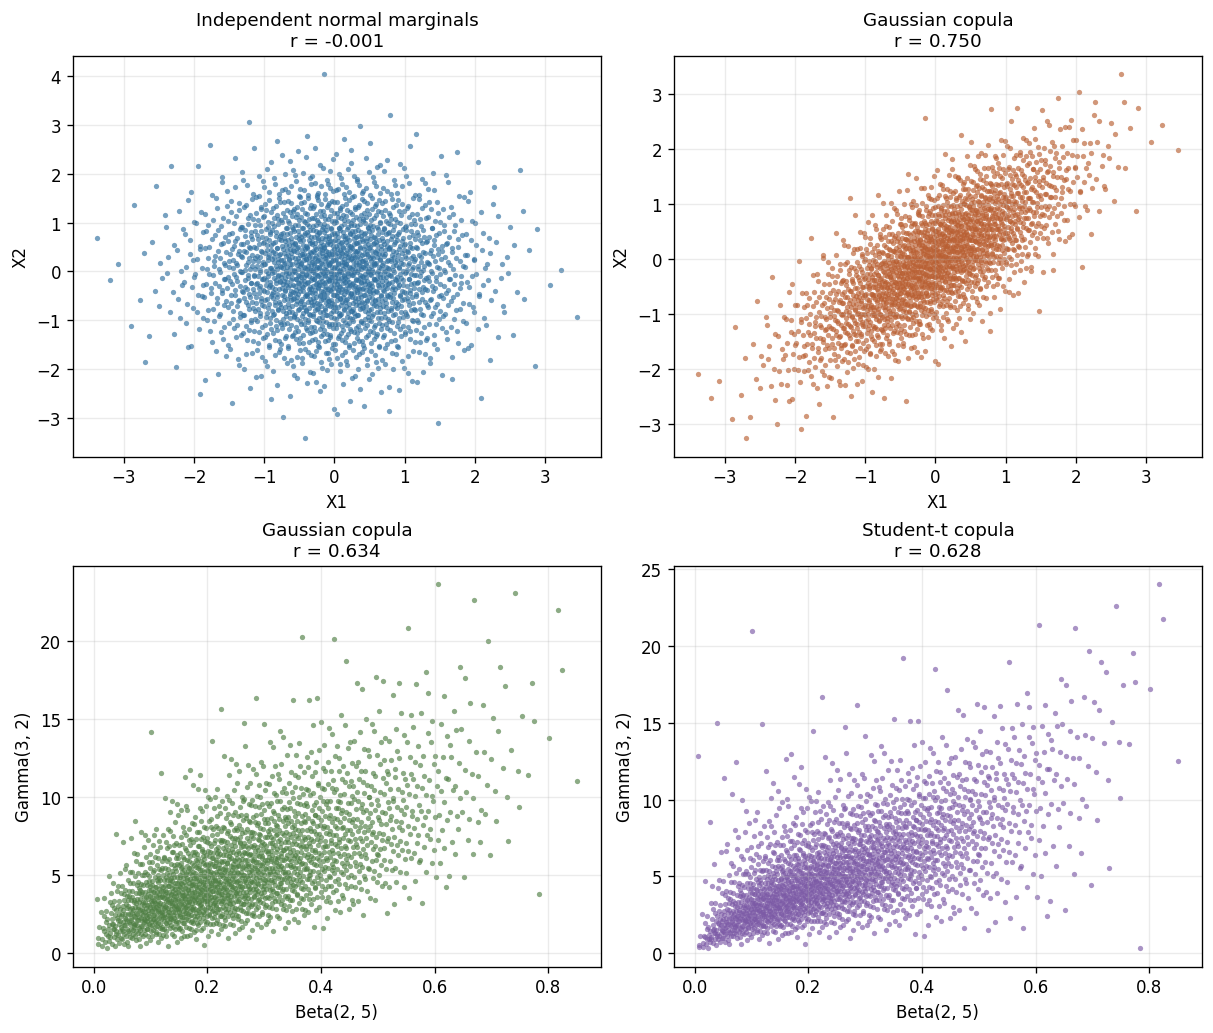

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8.5), constrained_layout=True)
axes = axes.ravel()

add_scatter(axes[0], samples["independent_normals"], "Independent normal marginals", "X1", "X2", "#2f6f9f")
add_scatter(axes[1], samples["positive_normal_gaussian"], "Gaussian copula", "X1", "X2", "#b95f32")
add_scatter(axes[2], samples["beta_gamma_gaussian"], "Gaussian copula", "Beta(2, 5)", "Gamma(3, 2)", "#4f7f44")
add_scatter(axes[3], samples["beta_gamma_student_t"], "Student-t copula", "Beta(2, 5)", "Gamma(3, 2)", "#7c5aa6")

plt.show()

### What The Four Panels Show

The top-left panel is the reference case: two independent standard normals. Since $\rho$ is essentially zero, the cloud is roughly round and has no clear diagonal direction.

The top-right panel keeps the same normal marginals but uses a Gaussian copula with positive correlation. The copula step creates correlated normal scores $Y = ZL^T$, where $LL^T = R$. The result is a slanted cloud, and the empirical $r$ is close to the requested correlation.

The bottom-left panel changes the marginals to $\mathrm{Beta}(2, 5)$ and $\mathrm{Gamma}(3, 2)$ while keeping Gaussian copula dependence. The beta coordinate is bounded in $[0, 1]$, and the gamma coordinate is positive and right-skewed, so the shape of the cloud changes even though the dependence still comes from the copula.

The bottom-right panel keeps the beta and gamma marginals but switches to a Student-t copula. The one-dimensional shapes are nearly the same, but the Student-t copula can create more joint extreme points.

## Show The Gaussian Copula Transform Workflow

### Gaussian Copula Transform

For the Gaussian copula, the transform temporarily moves uniform points into Gaussian space, adds correlation, and then maps back to the unit cube.

Let $\Phi$ be the standard normal CDF and $\Phi^{-1}$ be the standard normal quantile function. Let $R$ be a correlation matrix, and let $A$ be a matrix factor satisfying

$$
AA^T=R.
$$

The Gaussian copula sampling transform is:

$$
Z=\Phi^{-1}(U),
$$

$$
Z_{\mathrm{dep}}=ZA^T,
$$

$$
V=T(U)=\Phi(Z_{\mathrm{dep}}).
$$

The result $V$ has uniform one-dimensional marginals, but the coordinates have Gaussian-style dependence.

If final marginals are provided, they are applied afterward:

$$
X_j=F_j^{-1}(V_j).
$$

This is why a Gaussian copula with normal marginals overlaps with the existing multivariate Gaussian `TrueMeasure` case, while a Gaussian copula with beta, gamma, lognormal, or other marginals gives a dependent non-Gaussian distribution.

This section uses the same sampling-transform viewpoint as Cambou, Hofert, and Lemieux (2016, Section 1, p. 2): start with points on the unit cube and apply a copula sampling transform. Here that transform is written as $T$, while Cambou, Hofert, and Lemieux write it as $\phi_C$.

### What The Plot Shows

Start with independent uniforms $U = (U_1, U_2)$. Convert them to standard-normal scores with $Z_j = \Phi^{-1}(U_j)$. Add correlation with a Cholesky factor $L$, so $Y = ZL^T$. Convert back to uniforms with $V_j = \Phi(Y_j)$. Finally, apply the marginal quantile functions, for example $X_1 = F_{\mathrm{beta}}^{-1}(V_1)$ and $X_2 = F_{\mathrm{gamma}}^{-1}(V_2)$.

The middle panel is the copula stage: the points are still uniform, but now they are dependent. The last panel is the marginal stage: the dependence is still there, but the axes are beta and gamma instead of uniform.

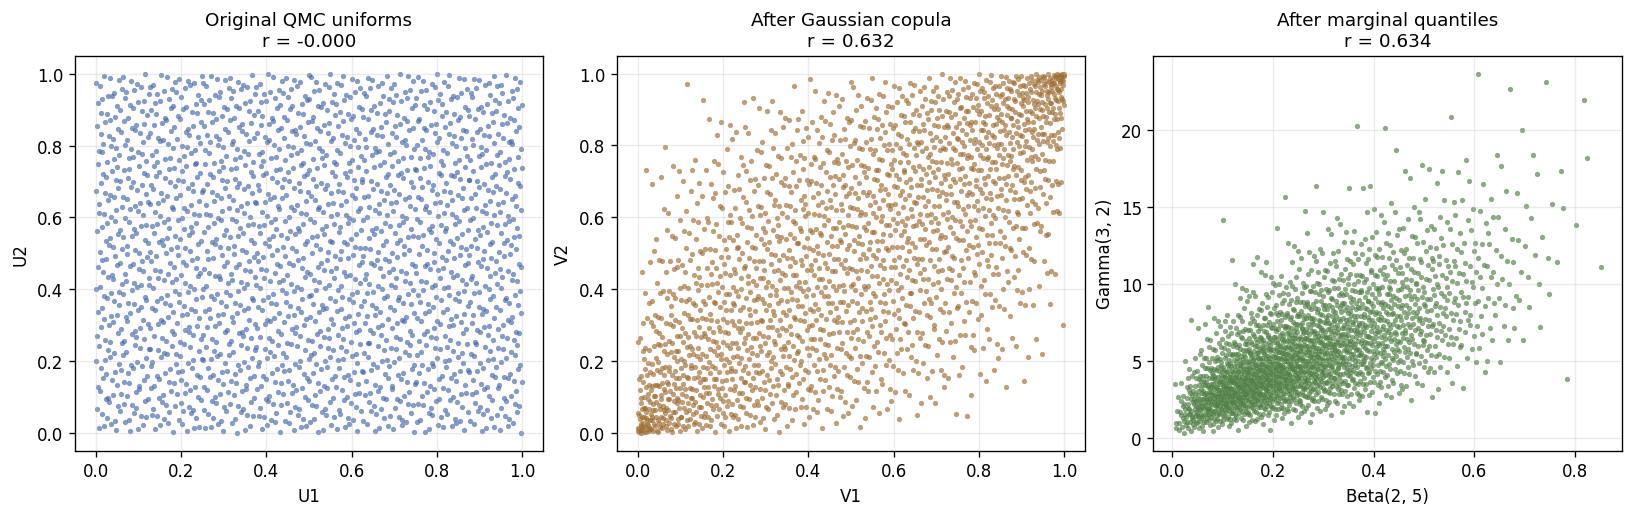

In [7]:
u = DigitalNetB2(2, seed=11)(n)
beta_gamma_corr = [[1.0, 0.65], [0.65, 1.0]]
dependent_u = gaussian_copula_uniforms(u, beta_gamma_corr)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2), constrained_layout=True)

add_scatter(axes[0], u, "Original QMC uniforms", "U1", "U2", "#4267ac")
add_scatter(axes[1], dependent_u, "After Gaussian copula", "V1", "V2", "#9f6b2f")
add_scatter(axes[2], samples["beta_gamma_gaussian"], "After marginal quantiles", "Beta(2, 5)", "Gamma(3, 2)", "#4f7f44")

plt.show()

### Interpreting The Workflow Plot

The first panel is the raw QMC input $U$. It fills the unit square evenly and has almost zero correlation.

The second panel is after the copula transform. The points are still uniform, but they are no longer independent. For the Gaussian copula this means $V_j = \Phi(Y_j)$, where $Y$ is a correlated normal vector. This is why the points lean along the diagonal while still staying inside $[0, 1]^2$.

The third panel is after the marginal quantile functions: $X_1 = F_{\mathrm{beta}}^{-1}(V_1)$ and $X_2 = F_{\mathrm{gamma}}^{-1}(V_2)$. The dependence pattern remains, but the values now live on beta and gamma scales.

## IID MC vs Randomized QMC For A Copula Integral

The plots above show what the copula transform does to the points. This section checks a different question: how the transformed points behave inside an integration estimate.

We keep the first integration experiment simple and two-dimensional. We use a Gaussian copula and stop at the copula-only output $V$ by calling `gen_copula_samples`. No marginal quantile functions are applied in this experiment, so here $X = V$.

Both IID MC and randomized QMC estimate the same expectation,

$$
\mathbb{E}[g(V)], \qquad g(V)=\max(V_1 + V_2 - 1.2, 0).
$$

This test function is deliberately not a simple linear sum. It only turns on when the two dependent uniforms are jointly large, so it is sensitive to the copula dependence structure.

For each sample size, both methods are passed through the same Gaussian copula transform. The solid line shows the median estimate across repeated runs. The shaded band shows the middle 50% of estimates, from the 25th percentile to the 75th percentile.

This comparison follows the QMC/copula sampling viewpoint in Cambou, Hofert, and Lemieux (2016, Section 1, p. 2, and Section 4, pp. 10-12), where the quality of QMC sampling for copula models is studied through transformed low-discrepancy point sets.

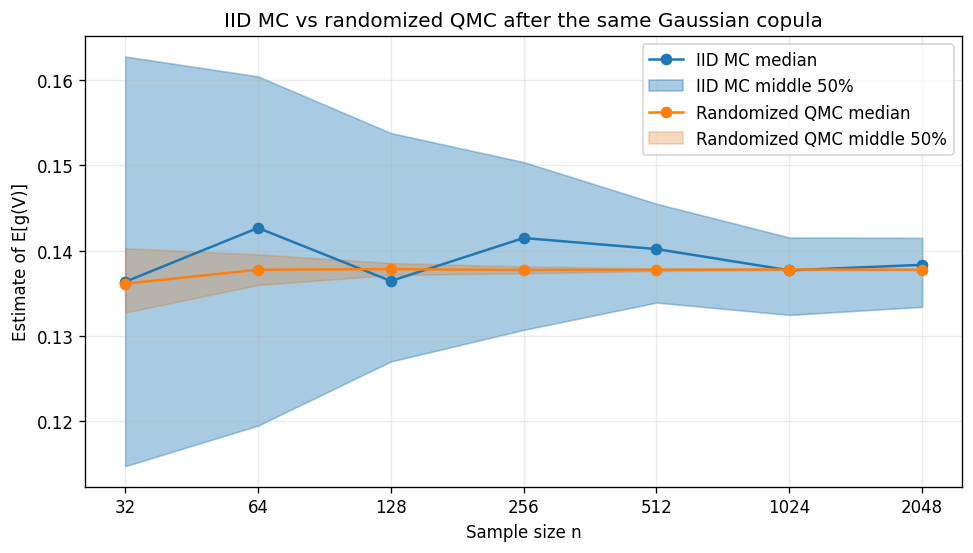

IID MC         n=2048 median=0.138327 middle-50% width=0.008070
Randomized QMC n=2048 median=0.137761 middle-50% width=0.000066


In [15]:
def copula_payoff(v):
    return np.maximum(v[..., 0] + v[..., 1] - 1.2, 0.0)


integration_sample_sizes = 2 ** np.arange(5, 12)
integration_repetitions = 100
integration_corr = np.array([[1.0, 0.7], [0.7, 1.0]])
uniform_marginals = [stats.uniform(), stats.uniform()]


def estimate_copula_payoff(sampler, n):
    # Stop at the copula-only layer U -> V for this integration experiment.
    copula_measure = GaussianCopula(
        sampler,
        marginals=uniform_marginals,
        correlation=integration_corr,
    )
    v = copula_measure.gen_copula_samples(n)
    return copula_payoff(v).mean()


iid_estimates = np.empty((integration_repetitions, len(integration_sample_sizes)))
qmc_estimates = np.empty_like(iid_estimates)

for rep in range(integration_repetitions):
    for i, n_i in enumerate(integration_sample_sizes):
        iid_sampler = IIDStdUniform(2, seed=5000 + rep)
        qmc_sampler = DigitalNetB2(2, seed=8000 + rep, randomize="LMS DS")
        iid_estimates[rep, i] = estimate_copula_payoff(iid_sampler, n_i)
        qmc_estimates[rep, i] = estimate_copula_payoff(qmc_sampler, n_i)

integration_estimates = {
    "IID MC": iid_estimates,
    "Randomized QMC": qmc_estimates,
}
integration_quantiles = {
    name: np.percentile(values, [25, 50, 75], axis=0)
    for name, values in integration_estimates.items()
}

fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
line_colors = {"IID MC": "tab:blue", "Randomized QMC": "tab:orange"}
fill_colors = {"IID MC": "#1F77B4", "Randomized QMC": "#DB6C0B"}

for name, quantiles in integration_quantiles.items():
    q25, median, q75 = quantiles
    ax.plot(integration_sample_sizes, median, marker="o", color=line_colors[name], label=f"{name} median")
    ax.fill_between(
        integration_sample_sizes,
        q25,
        q75,
        color=fill_colors[name],
        alpha=0.38 if name == "IID MC" else 0.25,
        label=f"{name} middle 50%",
    )

ax.set_xscale("log", base=2)
ax.set_xticks(integration_sample_sizes)
ax.set_xticklabels([str(n_i) for n_i in integration_sample_sizes])
ax.set_xlabel("Sample size n")
ax.set_ylabel("Estimate of E[g(V)]")
ax.set_title("IID MC vs randomized QMC after the same Gaussian copula")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

for name, quantiles in integration_quantiles.items():
    q25, median, q75 = quantiles
    width = q75[-1] - q25[-1]
    print(
        f"{name:14s} n={integration_sample_sizes[-1]:4d} "
        f"median={median[-1]:.6f} middle-50% width={width:.6f}"
    )

### Interpreting The IID MC vs QMC Plot

The two methods are estimating the same quantity, so their median lines should move toward the same value as $n$ grows. The solid line shows the median estimate across repeated runs. The shaded band shows the middle 50% of estimates, from the 25th percentile to the 75th percentile.

This example is an empirical comparison rather than a known-answer benchmark. Both IID MC and randomized QMC appear to converge toward the same value, but the randomized QMC estimates have much smaller spread across repetitions.

The important comparison is not just whether one median is slightly above or below the other at a given sample size. The useful signal is whether randomized QMC has a smaller spread while using the same copula transform and the same test function. That would mean the QMC point sets are giving more stable estimates for this dependence-sensitive integral.

## Gaussian vs Student-t Copula

The Gaussian and Student-t copulas can have similar correlation near the middle of the cloud, but they behave differently in the tails.

A Gaussian copula is mainly controlled by correlation. It does not force extreme values to happen together very often.

A Student-t copula has heavier joint tails. This means that if one coordinate is very large or very small, the other coordinate is more likely to also be extreme. Smaller $df$ means heavier tails. Here $df = 4$, so the effect is visible without being too extreme.

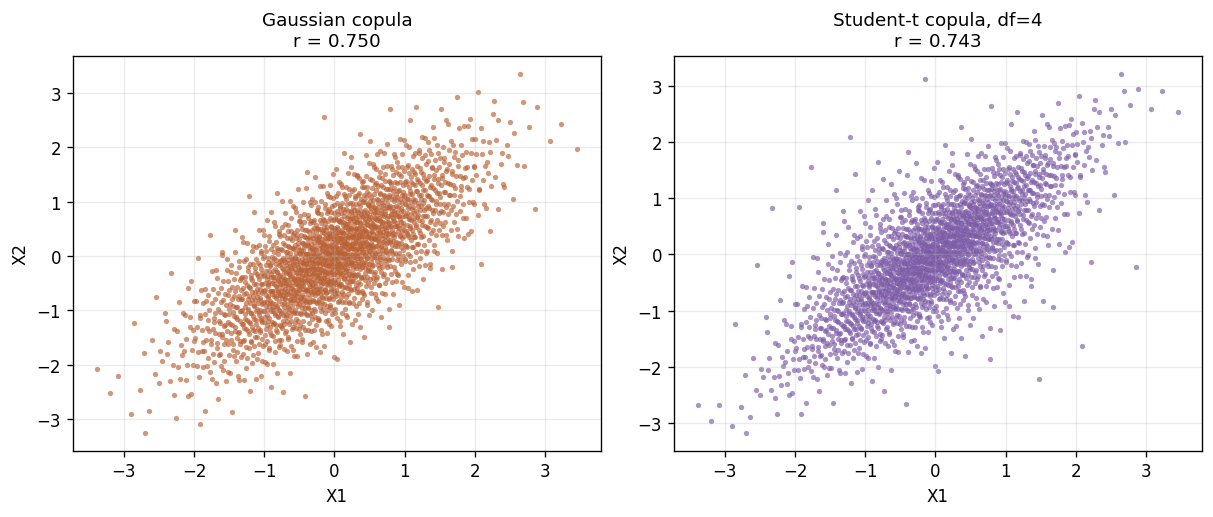

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), constrained_layout=True)

add_scatter(axes[0], samples["positive_normal_gaussian"], "Gaussian copula", "X1", "X2", "#b95f32")
add_scatter(axes[1], samples["student_t_normals"], "Student-t copula, df=4", "X1", "X2", "#7c5aa6")

plt.show()

### Interpreting Gaussian vs Student-t

The two panels have similar correlation, so the main difference is not the middle of the cloud. The difference is what happens near the extremes.

One way to describe this is with a conditional probability such as $P(U_2 > q \mid U_1 > q)$. For a Gaussian copula this becomes small as $q$ gets very close to $1$. For a Student-t copula with finite $df$, joint extremes remain more likely.

Here $df = 4$, so the Student-t copula still looks similar to the Gaussian copula in the center, but it has stronger joint-tail behavior.

## Clayton Copula Lower-Tail Dependence

The Clayton copula is useful when small values tend to happen together. In two dimensions, its lower-tail dependence number is $\lambda_L = 2^{-1/\theta}$, and its upper-tail dependence number is $\lambda_U = 0$.

The lower-tail and upper-tail dependence notation follows Nelsen (2006, Definition 5.4.1, p. 214). The Clayton tail-dependence formula follows Nelsen (2006, Corollary 5.4.3 and Example 5.22, pp. 215-216).

In words: if one coordinate is very small, Clayton makes the other coordinate more likely to be very small too. This is why Clayton is often used for joint downside risk, failure events, or settings where low values cluster.

The dashed lines mark the 5 percent lower-tail region. The printed conditional rate estimates $P(U_2 < 0.05 \mid U_1 < 0.05)$. The Gaussian comparison uses a correlation chosen to roughly match Kendall's $\tau$, a rank-based dependence measure. So the comparison is about tail shape, not just making one copula more correlated than the other.

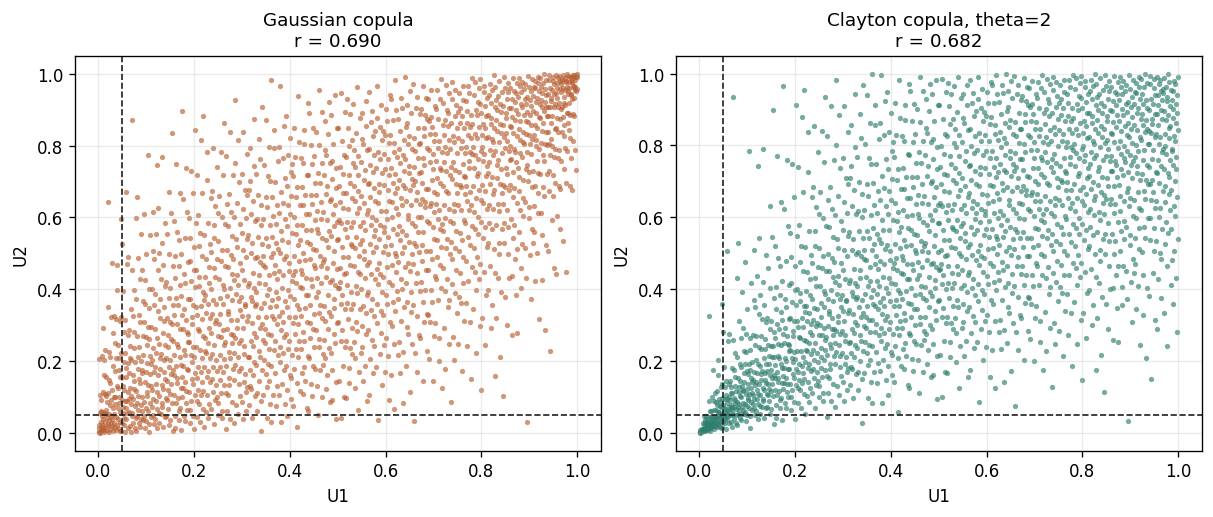

Gaussian lower-tail conditional rate: 0.392
Clayton lower-tail conditional rate:  0.725


In [10]:
def lower_tail_rate(sample, threshold=0.05):
    tail_0 = sample[:, 0] < threshold
    return np.mean(sample[tail_0, 1] < threshold)


fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), constrained_layout=True)

add_scatter(
    axes[0],
    samples["lower_tail_gaussian"],
    "Gaussian copula",
    "U1",
    "U2",
    "#b95f32",
)
add_scatter(
    axes[1],
    samples["lower_tail_clayton"],
    f"Clayton copula, theta={clayton_theta:g}",
    "U1",
    "U2",
    "#2f7f6f",
)

for ax in axes:
    ax.axvline(0.05, color="#1f1f1f", linewidth=1, linestyle="--")
    ax.axhline(0.05, color="#1f1f1f", linewidth=1, linestyle="--")

gaussian_lower = lower_tail_rate(samples["lower_tail_gaussian"])
clayton_lower = lower_tail_rate(samples["lower_tail_clayton"])

plt.show()

print(f"Gaussian lower-tail conditional rate: {gaussian_lower:.3f}")
print(f"Clayton lower-tail conditional rate:  {clayton_lower:.3f}")

### Interpreting The Clayton Output

The dashed square marks the event $U_1 < 0.05$ and $U_2 < 0.05$. The printed number estimates $P(U_2 < 0.05 \mid U_1 < 0.05)$, which means: if the first coordinate is in its lowest 5 percent, how often is the second coordinate also in its lowest 5 percent?

For the Gaussian comparison this rate is about $0.392$. For the Clayton copula it is about $0.725$. This means that, after observing the first coordinate in the bottom 5 percent, the second coordinate is much more likely to also be in the bottom 5 percent under Clayton.

For $\theta = 2$, Clayton's theoretical lower-tail number is $\lambda_L = 2^{-1/\theta} = 2^{-1/2} \approx 0.707$, while $\lambda_U = 0$. The observed lower-tail rate near $0.725$ agrees with the idea that Clayton clusters small values together.

## Gumbel Copula Upper-Tail Dependence

The Gumbel copula is useful when large values tend to happen together. In two dimensions, its upper-tail dependence number is $\lambda_U = 2 - 2^{1/\theta}$, and its lower-tail dependence number is $\lambda_L = 0$.

The upper-tail and lower-tail dependence notation follows Nelsen (2006, Definition 5.4.1, p. 214). The Gumbel-Hougaard tail-dependence formula follows Nelsen (2006, Corollary 5.4.3 and Example 5.22, pp. 215-216).

In words: if one coordinate is very large, Gumbel makes the other coordinate more likely to be very large too. This is useful for joint high-demand events, simultaneous high losses, flood or heat extremes, or any situation where high values cluster.

The dashed lines mark the 95 percent upper-tail region. The printed conditional rate estimates $P(U_2 > 0.95 \mid U_1 > 0.95)$. The Gaussian comparison again uses a similar rank-dependence level, so the plot highlights the upper-tail difference.

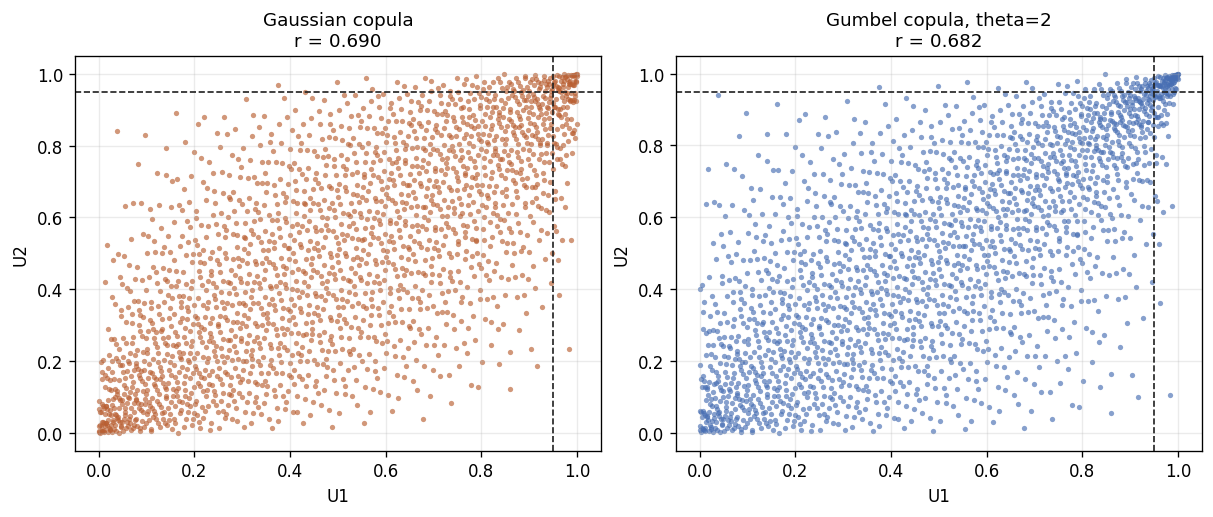

Gaussian upper-tail conditional rate: 0.392
Gumbel upper-tail conditional rate:   0.608


In [11]:
def upper_tail_rate(sample, threshold=0.95):
    tail_0 = sample[:, 0] > threshold
    return np.mean(sample[tail_0, 1] > threshold)


fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), constrained_layout=True)

add_scatter(
    axes[0],
    samples["upper_tail_gaussian"],
    "Gaussian copula",
    "U1",
    "U2",
    "#b95f32",
)
add_scatter(
    axes[1],
    samples["upper_tail_gumbel"],
    f"Gumbel copula, theta={gumbel_theta:g}",
    "U1",
    "U2",
    "#476eb3",
)

for ax in axes:
    ax.axvline(0.95, color="#1f1f1f", linewidth=1, linestyle="--")
    ax.axhline(0.95, color="#1f1f1f", linewidth=1, linestyle="--")

gaussian_upper = upper_tail_rate(samples["upper_tail_gaussian"])
gumbel_upper = upper_tail_rate(samples["upper_tail_gumbel"])

plt.show()

print(f"Gaussian upper-tail conditional rate: {gaussian_upper:.3f}")
print(f"Gumbel upper-tail conditional rate:   {gumbel_upper:.3f}")

### Interpreting The Gumbel Output

The dashed square now marks the event $U_1 > 0.95$ and $U_2 > 0.95$. The printed number estimates $P(U_2 > 0.95 \mid U_1 > 0.95)$, which means: if the first coordinate is in its highest 5 percent, how often is the second coordinate also in its highest 5 percent?

The Gaussian comparison gives an upper-tail conditional rate around $0.392$. The Gumbel copula gives about $0.608$, so a large value in the first coordinate makes a large value in the second coordinate more likely than the Gaussian copula would suggest.

For $\theta = 2$, Gumbel's theoretical upper-tail number is $\lambda_U = 2 - 2^{1/\theta} = 2 - \sqrt{2} \approx 0.586$, while $\lambda_L = 0$. The observed upper-tail rate near $0.608$ agrees with the idea that Gumbel clusters large values together.

## Frank Copula Symmetric Dependence

Frank is a symmetric copula. Unlike Clayton and Gumbel, it does not focus on dependence in only one tail.

The statement that the standard Frank copula has no lower or upper tail dependence follows Nelsen (2006, Example 5.22, pp. 215-216), where the Frank family is included among the Archimedean families with $\lambda_L=\lambda_U=0$.

In words: Frank is useful when variables move together across the distribution, but you do not want to say that the dependence mainly comes from very small values or very large values.

The bar plot compares lower-tail and upper-tail conditional rates. They should be more balanced than the Clayton and Gumbel examples.

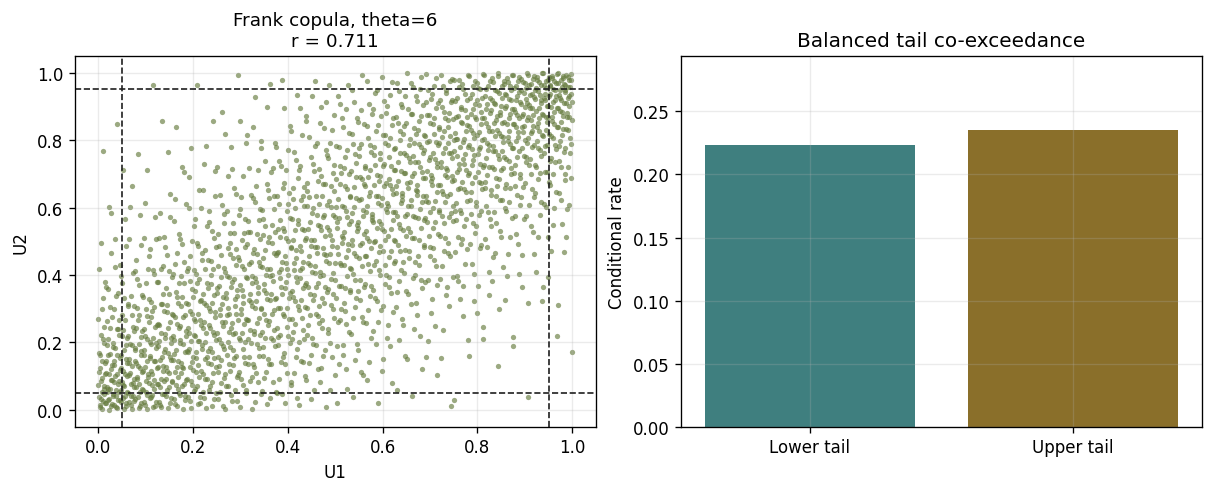

Frank lower-tail conditional rate: 0.223
Frank upper-tail conditional rate: 0.235


In [12]:
frank_lower = lower_tail_rate(samples["frank_uniforms"])
frank_upper = upper_tail_rate(samples["frank_uniforms"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

add_scatter(
    axes[0],
    samples["frank_uniforms"],
    f"Frank copula, theta={frank_theta:g}",
    "U1",
    "U2",
    "#667c3e",
)
for threshold in [0.05, 0.95]:
    axes[0].axvline(threshold, color="#1f1f1f", linewidth=1, linestyle="--")
    axes[0].axhline(threshold, color="#1f1f1f", linewidth=1, linestyle="--")

axes[1].bar(
    ["Lower tail", "Upper tail"],
    [frank_lower, frank_upper],
    color=["#3f7f7f", "#8a6f2a"],
)
axes[1].set_title("Balanced tail co-exceedance")
axes[1].set_ylabel("Conditional rate")
axes[1].set_ylim(0, max(frank_lower, frank_upper) * 1.25)

plt.show()

print(f"Frank lower-tail conditional rate: {frank_lower:.3f}")
print(f"Frank upper-tail conditional rate: {frank_upper:.3f}")

### Interpreting The Frank Output

The Frank sample has positive dependence, but the lower-tail and upper-tail conditional rates are close: about $0.223$ and $0.235$ in this run.

That is the key point of this example. Frank can create association without saying that dependence is mainly a lower-tail event or mainly an upper-tail event. In tail-dependence notation, the standard Frank copula has $\lambda_L = \lambda_U = 0$, so it does not force extreme-tail clustering.

Use Frank when the dependence looks fairly balanced across the distribution. Use Clayton or Gumbel when there is a reason to emphasize one side of the tail.

## Check The Marginals

A copula should change how coordinates move together without changing each coordinate's requested marginal distribution.

This final check uses the Student-t copula sample with beta and gamma marginals. The histograms are the simulated marginal samples. The black curves are the target SciPy PDFs. If the copula is behaving correctly, the histograms should follow the beta and gamma shapes even though the two coordinates are dependent.

This check is important: the copula controls how coordinates move together, while each marginal quantile function (`ppf`, SciPy's inverse CDF function) still controls the distribution of its own coordinate.

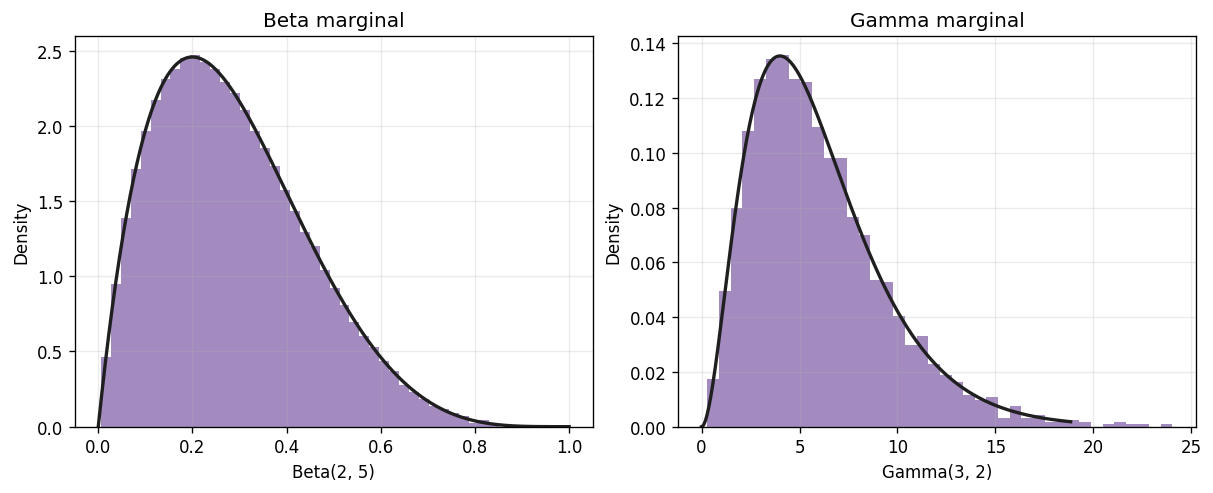

In [13]:
beta_dist = stats.beta(a=2, b=5)
gamma_dist = stats.gamma(a=3, scale=2)
beta_gamma_samples = samples["beta_gamma_student_t"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

x_beta = np.linspace(0, 1, 400)
axes[0].hist(beta_gamma_samples[:, 0], bins=40, density=True, alpha=0.7, color="#7c5aa6")
axes[0].plot(x_beta, beta_dist.pdf(x_beta), color="#1f1f1f", linewidth=2)
axes[0].set_title("Beta marginal")
axes[0].set_xlabel("Beta(2, 5)")
axes[0].set_ylabel("Density")

x_gamma = np.linspace(0, np.quantile(beta_gamma_samples[:, 1], 0.995), 400)
axes[1].hist(beta_gamma_samples[:, 1], bins=40, density=True, alpha=0.7, color="#7c5aa6")
axes[1].plot(x_gamma, gamma_dist.pdf(x_gamma), color="#1f1f1f", linewidth=2)
axes[1].set_title("Gamma marginal")
axes[1].set_xlabel("Gamma(3, 2)")
axes[1].set_ylabel("Density")

plt.show()

### Interpreting The Marginal Check

The purple histograms come from dependent samples, but each coordinate should still follow its own requested marginal distribution. The black curves are the target PDFs.

For the beta coordinate, the target distribution is $\mathrm{Beta}(2, 5)$, with mean $2/7 \approx 0.286$ and support $[0, 1]$. For the gamma coordinate, the target distribution is $\mathrm{Gamma}(a=3, \mathrm{scale}=2)$, with mean $6$ and support on positive values.

The histograms line up with the black curves, which shows that the copula did not replace the marginals. It only changed the dependence before the marginal quantile functions (`ppf`, SciPy's inverse CDF function) mapped each coordinate to its final scale.

## What This Demonstrates

These examples show that copula-based `TrueMeasure` classes can fit naturally into QMCPy's existing transform workflow. The copula controls the dependence structure, while the marginal quantile functions control the final one-dimensional distributions.

The main idea is the same throughout the notebook: start with QMC uniforms, reshape their dependence with a copula, and then use marginal quantile functions to put each coordinate on the scale you actually want.

The examples cover different dependence behaviors:

- Gaussian copula: correlation-based dependence
- Student-t copula: stronger joint-tail behavior
- Clayton copula: lower-tail dependence, now with general-dimensional support for $\theta > 0$
- Gumbel copula: upper-tail dependence, now with general-dimensional support for $\theta \geq 1$
- Frank copula: symmetric dependence without strong tail emphasis